# 실험 결과

무엇과 무엇을 비교했고 어느 쪽이 나았는지를 축마다 그림 하나로 봅니다.
기준선은 한 클래스만 답하는 경우입니다. 클래스 가중치를 같게 주면 W 를 답하고 macro-F1 0.126 입니다.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

ROOT = Path.cwd().parent
RUNS = ROOT / "runs"
BASELINE = 0.1261
BLUE, RED, GREY = "#4C78A8", "#C44E52", "#BAB0AC"


def load_runs() -> pd.DataFrame:
    """축을 훑은 탐색 단계 실행을 읽는다. 개선 단계는 아래에서 따로 읽는다."""
    rows = []
    for path in sorted(RUNS.glob("*/*/*/*/*.json")):
        if path.name not in ("metrics.json", "summary.json"):
            continue
        model, preprocess, options, _ = path.parent.relative_to(RUNS).parts
        blob = json.loads(path.read_text())
        scores = blob["mean"] if path.name == "summary.json" else blob["pooled"]
        filt, norm, ctx = preprocess.split("-")
        rows.append(
            {"model": model, "filter": filt, "normalize": norm, "context": ctx, "options": options}
            | {k: v for k, v in scores.items() if isinstance(v, int | float)}
        )
    return pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)


def load_improvements() -> pd.DataFrame:
    """기준선에 무언가를 더해 본 실행. 폴더 이름이 곧 더한 것이다."""
    rows = []
    for path in sorted(RUNS.glob("improve/*/*/metrics.json")):
        man = json.loads((path.parent / "manifest.json").read_text())
        rows.append(
            {"added": path.parent.parent.name, "n_features": man["n_features"]}
            | json.loads(path.read_text())["pooled"]
        )
    return pd.DataFrame(rows)


runs = load_runs()
print(f"실행 {len(runs)}건")
runs.head(8)[["model", "filter", "normalize", "context", "options", "macro_f1"]].round(4)

실행 30건


,model,filter,normalize,context,options,macro_f1
0,ensemble,zerophase,expanding,smooth,members-histgb+lightgbm+xgboost+catboost,0.8398
1,catboost,zerophase,expanding,smooth,cw-none,0.8391
2,ensemble,zerophase,expanding,shift,members-histgb+lightgbm+xgboost+catboost,0.8386
3,catboost,zerophase,expanding,smooth,cw-balanced,0.8381
4,xgboost,zerophase,expanding,shift,cw-balanced,0.8379
5,xgboost,zerophase,expanding,smooth,cw-balanced,0.8378
6,catboost,zerophase,expanding,smooth,cw-balanced-no_distance,0.8356
7,catboost,zerophase,expanding,shift,cw-balanced,0.8353


## 전처리

필터 3가지와 문맥 3가지를 조합해 9번 돌렸습니다.
모델은 histgb 로 고정해서 차이가 전처리에서만 오게 했습니다.

문맥 3.3%p, 필터 0.8%p


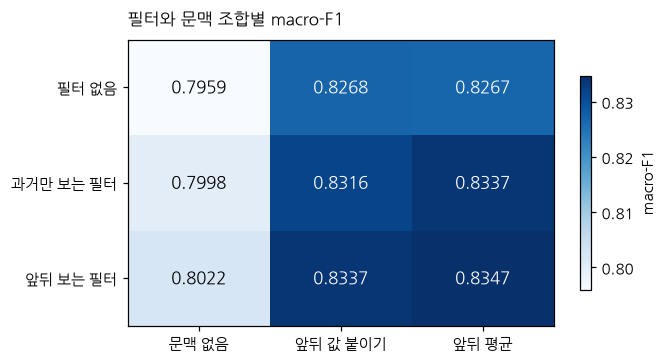

In [2]:
grid = (
    runs.query("model == 'histgb' and normalize == 'expanding'")
    .groupby(["filter", "context"])["macro_f1"]
    .max()
    .unstack("context")
    .reindex(index=["none", "causal", "zerophase"], columns=["none", "shift", "smooth"])
)

fig, ax = plt.subplots(figsize=(6.2, 3.4))
im = ax.imshow(grid, cmap="Blues", aspect="auto")
ax.set_xticks(range(3), ["문맥 없음", "앞뒤 값 붙이기", "앞뒤 평균"])
ax.set_yticks(range(3), ["필터 없음", "과거만 보는 필터", "앞뒤 보는 필터"])
for i in range(3):
    for j in range(3):
        v = grid.iloc[i, j]
        ax.text(
            j,
            i,
            f"{v:.4f}",
            ha="center",
            va="center",
            fontsize=11,
            color="white" if v > grid.values.mean() else "black",
        )
ax.set_title("필터와 문맥 조합별 macro-F1", fontsize=11, loc="left", pad=10)
fig.colorbar(im, shrink=0.75, label="macro-F1")
fig.tight_layout()

ctx_gain = (grid[["shift", "smooth"]].max().max() - grid["none"].max()) * 100
flt_gain = (grid.loc["zerophase"].max() - grid.loc["none"].max()) * 100
print(f"문맥 {ctx_gain:.1f}%p, 필터 {flt_gain:.1f}%p")

문맥을 더하면 3.3%p 오르고 필터를 걸면 0.8%p 오릅니다. 문맥이 네 배 큽니다.

앞뒤 값을 그대로 붙이는 방식과 앞뒤를 평균하는 방식은 0.1%p 차이라 사실상 같습니다.
열 수가 481개와 289개로 차이가 나므로 적은 쪽을 골랐습니다.

## 모델

전처리를 앞뒤 보는 필터와 앞뒤 평균으로 고정하고 모델만 갈아 끼웠습니다.

선형 대비 부스팅 2.6%p


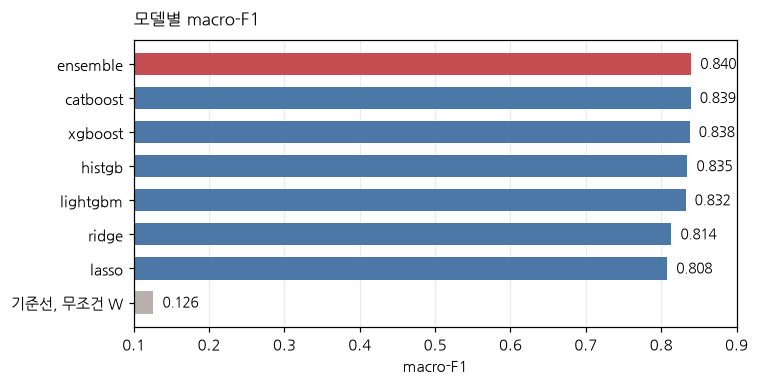

In [3]:
best = (
    runs.query("context == 'smooth' and filter == 'zerophase' and normalize == 'expanding'")
    .groupby("model")["macro_f1"]
    .max()
    .drop(index=["cnn", "lstm"], errors="ignore")
    .sort_values()
)

labels = ["기준선, 무조건 W" if m == "majority" else m for m in best.index]
colors = [BLUE] * len(best)
colors[0], colors[-1] = GREY, RED

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(labels, best.values, color=colors, height=0.65)
for i, v in enumerate(best.values):
    ax.text(v + 0.012, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0.10, 0.90)
ax.set_xlabel("macro-F1")
ax.set_title("모델별 macro-F1", fontsize=11, loc="left", pad=10)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()

(ROOT / "assets").mkdir(exist_ok=True)
fig.savefig(ROOT / "assets/models.png", bbox_inches="tight")

linear = best[["ridge", "lasso"]].max()
boost = best.drop(index=["majority", "ridge", "lasso"], errors="ignore").max()
print(f"선형 대비 부스팅 {(boost - linear) * 100:.1f}%p")

선형에서 부스팅으로 오면 2.6%p 오릅니다. 이 문제에 비선형이 필요하다는 뜻입니다.

부스팅 네 종류는 0.5%p 안쪽으로 붙어 있습니다. 어느 것을 골라도 큰 차이가 없습니다.
앙상블이 가장 높지만 catboost 단일과 0.2%p 차이라, 판단 근거를 캘 수 있는 단일 모델을 기준으로 삼았습니다.

## 특징을 하나씩 빼면

catboost 를 고정하고 채널, 거리 기반 특징, 정규화를 각각 빼서 얼마나 떨어지는지 봤습니다.

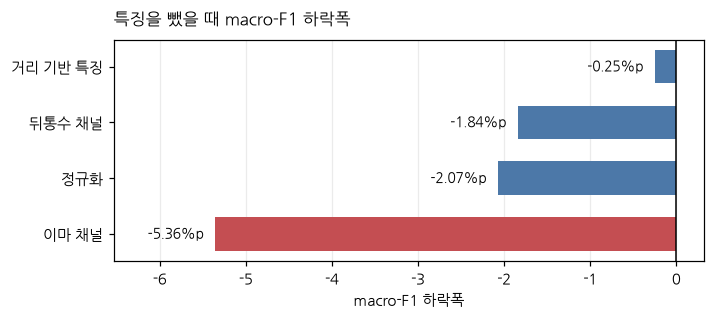

In [4]:
full = runs.query(
    "model == 'catboost' and options == 'cw-balanced' "
    "and context == 'smooth' and normalize == 'expanding'"
)["macro_f1"].max()

drops = {}
for opt, label in [  # noqa: B007
    ("cw-balanced-no_distance", "거리 기반 특징"),
    ("cw-balanced-fpz_only", "뒤통수 채널"),
    ("cw-balanced-pz_only", "이마 채널"),
]:
    hit = runs.query("model == 'catboost' and options == @opt")
    if len(hit):
        drops[label] = (hit["macro_f1"].max() - full) * 100
nonorm = runs.query("model == 'catboost' and normalize == 'none'")
if len(nonorm):
    drops["정규화"] = (nonorm["macro_f1"].max() - full) * 100

order = sorted(drops, key=drops.get)
low = min(drops.values())

fig, ax = plt.subplots(figsize=(6.6, 3.0))
ax.barh(order, [drops[k] for k in order], color=[RED] + [BLUE] * (len(order) - 1), height=0.6)
ax.set_xlim(low * 1.22, low * -0.06)
for i, k in enumerate(order):
    ax.text(
        drops[k] - abs(low) * 0.025, i, f"{drops[k]:.2f}%p", va="center", ha="right", fontsize=9
    )
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("macro-F1 하락폭")
ax.set_title("특징을 뺐을 때 macro-F1 하락폭", fontsize=11, loc="left", pad=10)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()

이마 채널을 빼면 5.36%p 떨어져서 가장 큽니다. 뒤통수 채널을 뺄 때의 세 배입니다.
웨어러블은 이마에 붙이는 것이 자연스러운데, 성능 면에서도 그쪽이 맞다는 근거가 됩니다.

정규화를 빼면 2.07%p 떨어집니다. 사람마다 두개골 두께와 전극 접촉이 달라 진폭 자체가
다르기 때문에, 이것을 맞추지 않으면 모델이 사람 차이부터 배워야 합니다.

거리 기반 특징은 0.25%p 뿐이라 없어도 됩니다.

100개면 전체 289개와 0.3%p 안쪽으로 붙습니다. 절반 이상은 없어도 됩니다.

20개까지 줄이면 3.6%p 떨어지므로 그 아래로는 무리입니다.

## 얼마나 기다릴 것인가

특징마다 계산에 필요한 미래 시간을 기록해 두었습니다.
허용 지연을 정하면 쓸 수 있는 특징이 자동으로 걸러집니다.

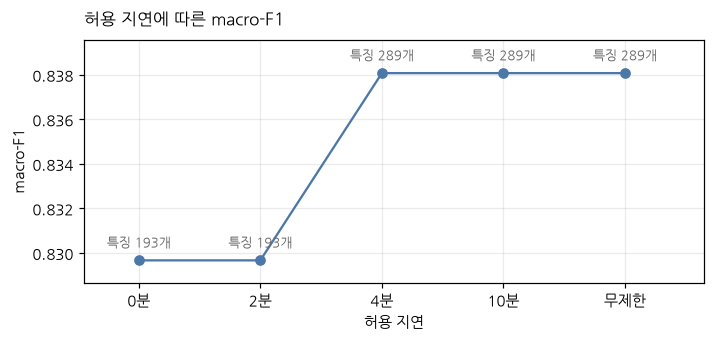

In [6]:
budget = pd.DataFrame(json.loads((RUNS / "curves/budget_curve.json").read_text())["points"])
budget["label"] = budget["budget_min"].map(lambda v: "무제한" if not np.isfinite(v) else f"{v:g}분")

fig, ax = plt.subplots(figsize=(6.6, 3.2))
x = np.arange(len(budget))
ax.plot(x, budget["macro_f1"], marker="o", color=BLUE)
ax.set_xticks(x, budget["label"])
ax.set_xlim(-0.45, len(budget) - 0.35)
ax.set_ylim(budget["macro_f1"].min() - 0.001, budget["macro_f1"].max() + 0.0015)
for i, (v, n) in enumerate(zip(budget["macro_f1"], budget["n_features"], strict=True)):
    ax.annotate(
        f"특징 {n}개",
        (i, v),
        textcoords="offset points",
        xytext=(0, 9),
        ha="center",
        fontsize=8.5,
        color="#666",
    )
ax.set_xlabel("허용 지연")
ax.set_ylabel("macro-F1")
ax.set_title("허용 지연에 따른 macro-F1", fontsize=11, loc="left", pad=10)
ax.grid(alpha=0.25)
fig.tight_layout()

즉시 답해야 하면 0.84%p 를 잃습니다. 이것이 실시간의 값입니다.

4분만 기다리면 무제한과 같아집니다. 앞뒤 평균이 앞으로 3.5분을 보기 때문에,
그 이상 기다려도 새로 쓸 수 있는 특징이 없습니다.

## 신경망이 앞뒤를 얼마나 봐야 하나

원신호를 그대로 넣는 신경망에서 함께 보는 조각 수를 바꿔가며 돌렸습니다.
창 1 은 조각 하나만 보는 경우입니다. 창 15 는 부스팅의 앞뒤 평균과 크기도 지연도 같습니다.

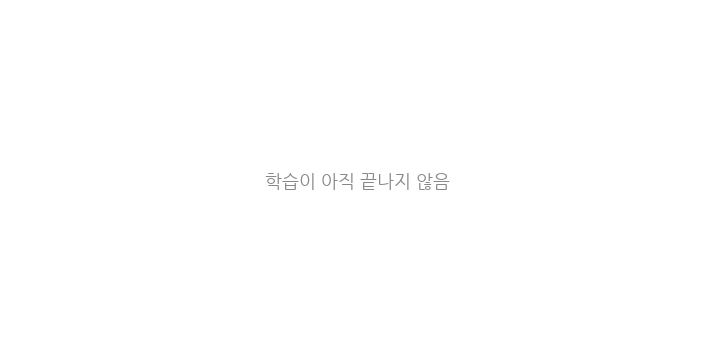

In [7]:
deep = runs[runs["context"].str.startswith("win")].copy()
deep["window"] = deep["context"].str.removeprefix("win").astype(int)
deep = deep.groupby("window")["macro_f1"].max().sort_index()

fig, ax = plt.subplots(figsize=(6.6, 3.4))
if deep.empty:
    ax.text(
        0.5, 0.5, "학습이 아직 끝나지 않음", ha="center", va="center", fontsize=12, color="#888"
    )
    ax.set_axis_off()
else:
    ax.plot(deep.index, deep.values, marker="o", color=BLUE)
    for w, v in deep.items():
        ax.annotate(
            f"{v:.3f}", (w, v), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8.5
        )
    ax.axhline(full, color=RED, ls="--", lw=1.2)
    ax.text(
        deep.index.max(),
        full - 0.002,
        f"부스팅 {full:.3f}",
        ha="right",
        va="top",
        fontsize=9,
        color=RED,
    )
    ax.axvline(15, color=GREY, ls=":", lw=1.2)
    ax.text(15.8, deep.min(), "부스팅과 같은 창", fontsize=8.5, color="#666", va="bottom")
    ax.set_xlabel("함께 보는 조각 수")
    ax.set_ylabel("macro-F1")
    ax.set_title("함께 보는 조각 수에 따른 macro-F1", fontsize=11, loc="left", pad=10)
    ax.grid(alpha=0.25)
fig.tight_layout()

학습이 끝나면 여기에 결과를 정리합니다.

## 무엇이 성능을 만들었나

지금까지의 차이를 한자리에 모읍니다.

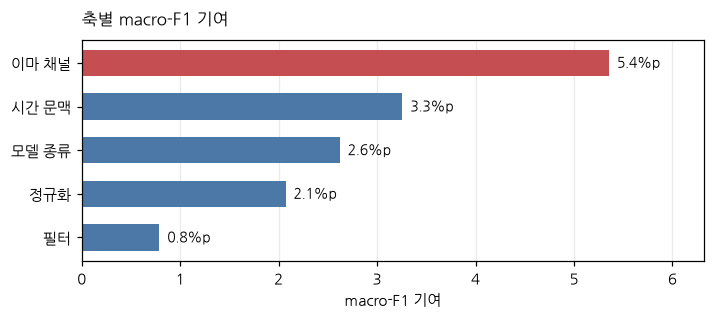

In [8]:
g = runs.query("model == 'histgb' and normalize == 'expanding'")
contrib = {
    "시간 문맥": (
        g.query("context != 'none'")["macro_f1"].max()
        - g.query("context == 'none'")["macro_f1"].max()
    )
    * 100,
    "필터": (
        g.query("filter == 'zerophase'")["macro_f1"].max()
        - g.query("filter == 'none'")["macro_f1"].max()
    )
    * 100,
    "모델 종류": (boost - linear) * 100,
}
for label in ("정규화", "이마 채널"):
    if label in drops:
        contrib[label] = -drops[label]

order = sorted(contrib, key=contrib.get)
fig, ax = plt.subplots(figsize=(6.6, 3.0))
ax.barh(order, [contrib[k] for k in order], color=[BLUE] * (len(order) - 1) + [RED], height=0.6)
for i, k in enumerate(order):
    ax.text(contrib[k] + 0.08, i, f"{contrib[k]:.1f}%p", va="center", fontsize=9)
ax.set_xlim(0, max(contrib.values()) * 1.18)
ax.set_xlabel("macro-F1 기여")
ax.set_title("축별 macro-F1 기여", fontsize=11, loc="left", pad=10)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(ROOT / "assets/contribution.png", bbox_inches="tight")

모델을 무엇으로 고르느냐보다 입력을 어떻게 만드느냐가 큽니다.

채널 선택과 시간 문맥과 정규화를 합치면 10%p 가 넘습니다.
모델 종류를 바꿔 얻은 것은 2.6%p 이고, 하이퍼파라미터를 조정해 얻은 것은 0.5%p 미만입니다.